## **ADIDAS US Sales Analysis & Demand Forecasting**

*   Valeria Carolina GÓMEZ AUSTRIA
*   Tuva-Lisa JARVENSTRAND
*   Zora WOLBERT
*   Mariana WOLFF VEGA
*   Natalia YUDICO SUAREZ

**Company Overview**

---
Adidas is a German multinational corporation founded in 1949 that designs, manufactures, and markets sportswear, footwear, and accessories. It started as a family business and quickly gained recognition for its innovative designs. Today, it is one of the largest sportswear companies in the world, serving both professional athletes and everyday consumers.

The company operates through a global network of retail stores, e-commerce platforms, and wholesale partnerships, offering products that combine performance, innovation, and lifestyle appeal. Adidas has built a strong brand identity centered around sport, creativity, and sustainability.

In [ ]:
# Import libraries

import numpy as np #to compute
import pandas as pd #to read the data
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
  accuracy_score,
  recall_score,
  f1_score,
  roc_auc_score,
  confusion_matrix,
  classification_report,
  mean_absolute_error,
  mean_squared_error,
  r2_score
)

# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [ ]:
# Upload Excel File

from google.colab import files
uploaded = files.upload()

Saving Adidas US Sales Datasets.xlsx to Adidas US Sales Datasets.xlsx


In [ ]:
# Read Excel file

import pandas as pd
df = pd.read_excel('Adidas US Sales Datasets.xlsx', header = 4)
df = df.drop(df.columns[0], axis=1)
df

# axis = 0 -> lines,  axis = 1 -> columns

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.000,1200,600000.000,300000.000,0.500,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.000,1000,500000.000,150000.000,0.300,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.000,1000,400000.000,140000.000,0.350,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.000,850,382500.000,133875.000,0.350,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.000,900,540000.000,162000.000,0.300,In-store
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Men's Apparel,50.000,64,3200.000,896.000,0.280,Outlet
9644,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Women's Apparel,41.000,105,4305.000,1377.600,0.320,Outlet
9645,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Street Footwear,41.000,184,7544.000,2791.280,0.370,Outlet
9646,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Athletic Footwear,42.000,70,2940.000,1234.800,0.420,Outlet


In [ ]:
# Display the dimensions

df.shape

(9648, 13)

In [ ]:
# Information about dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(6)
memory usage: 980.0+ KB


The dataset contains **9,648 observations** and **13 variables**, combining geographical and financial information related to Adidas' sales transactions in the USA during 2020 and 2021.

The variables include:
*   Categorical variables (6): Retailer, Region, State, City, Product, Sales Method
*   Numerical variables (6): Price per Unit, Units Sold, Total Sales, Operating Profit, Operating Margin, Retailer ID
*   Temporal variable (1): Invoice Date


**Data Cleaning**

In [ ]:
# List of missing values by column

df.isna().sum()

,0
Retailer,0
Retailer ID,0
Invoice Date,0
Region,0
State,0
City,0
Product,0
Price per Unit,0
Units Sold,0
Total Sales,0


In [ ]:
# Check duplicate values

df.duplicated().sum()

np.int64(0)

In [ ]:
# Descriptive Statistics for numerical columns

print("Descriptive Statistics for Numerical Columns")
print("")
df.describe()

Descriptive Statistics for Numerical Columns



,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9648.000,9648,9648.000,9648.000,9648.000,9648.000,9648.000
mean,1173849.724,2021-05-10 15:20:44.776119296,45.217,256.930,93273.438,34425.245,0.423
min,1128299.000,2020-01-01 00:00:00,7.000,0.000,0.000,0.000,0.100
25%,1185732.000,2021-02-17 00:00:00,35.000,106.000,4254.500,1921.753,0.350
50%,1185732.000,2021-06-04 00:00:00,45.000,176.000,9576.000,4371.420,0.410
75%,1185732.000,2021-09-16 00:00:00,55.000,350.000,150000.000,52062.500,0.490
max,1197831.000,2021-12-31 00:00:00,110.000,1275.000,825000.000,390000.000,0.800
std,26360.377,NaN,14.705,214.252,141916.017,54193.114,0.097


The **average price per unit is 45.22**, ranging from 7 to 110, indicating a diverse product portfolio with different pricing strategies.

In terms of demand, the **average units sold is 257**, but with a high **standard deviation (214)**, suggesting strong variability in sales volume across transactions. A minimum value of 0 also indicates that some transactions may correspond to returns, cancellations, or data inconsistencies.

Total Sales show a highly skewed distribution, with a mean of **93,273** and a maximum of **825,000**.

The **Operating Margin averages 42.3%**, with relatively low variability (std: 0.097), indicating that while sales and profit fluctuate, the firm's profitability ratio remains relatively stable across transactions.

In [ ]:
# Descriptive Statistics for Categorical Columns

print("Descriptive Statistics for Categorical Columns")
print()
df.describe(include = 'object')

Descriptive Statistics for Categorical Columns



,Retailer,Region,State,City,Product,Sales Method
count,9648,9648,9648,9648,9648,9648
unique,6,5,50,52,6,3
top,Foot Locker,West,Texas,Portland,Men's Street Footwear,Online
freq,2637,2448,432,360,1610,4889


# **Data Visualization and Manipulation**


In [ ]:
# Create new "date" variables

df["Year"] = df["Invoice Date"].dt.year
df["Month"] = df["Invoice Date"].dt.month
df["Day_of_week"] = df["Invoice Date"].dt.dayofweek
df['Day_Name'] = df['Invoice Date'].dt.day_name()
df["Month_Name"] = df["Invoice Date"].dt.month_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = ["January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Convert 'Day_Name'  and 'Month_Name' to a Categorical type with the specified order
df['Day_Name'] = pd.Categorical(df['Day_Name'], categories=day_order, ordered=True)
df['Month_Name'] = pd.Categorical(df['Month_Name'], categories=month_order, ordered=True)

## Sales over time

Text(0, 0.5, 'Sales (USD)')

<Figure size 640x480 with 0 Axes>

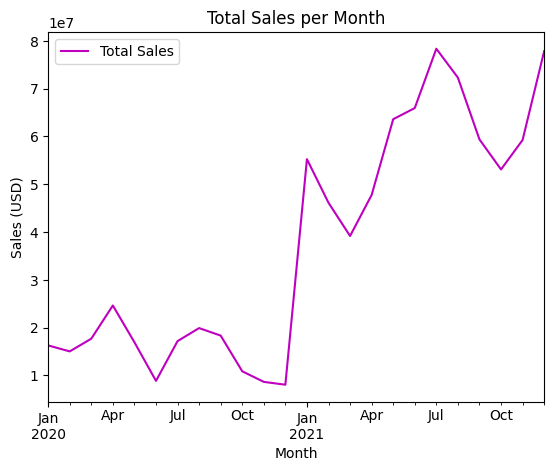

In [ ]:
# Line Graph of Sales over time

plt.figure()
df["YearMonth"] = df["Invoice Date"].dt.to_period("M")
graph1 = df.groupby("YearMonth")["Total Sales"].sum().reset_index()
graph1.plot(kind="line", x="YearMonth", y="Total Sales", color="m")
plt.title("Total Sales per Month")
plt.xlabel("Month")
plt.ylabel("Sales (USD)")

The analysis of total sales over time reveals a strong **upward trend**, with a significant increase from 2020 to 2021, which may suggest post-COVID recovery. This growth is particularly evident at the beginning of 2021, where sales levels rise sharply compared to the previous year.

Additionally, the graph shows clear **seasonal patterns, with peaks observed during mid-year (July–August) and at the end of the year (December)**.

In [ ]:
# Top 3 periods with higher sales

top3_period_sales = df.groupby(df["Invoice Date"].dt.to_period("M"))["Total Sales"].sum().reset_index().sort_values(by="Total Sales", ascending=False).head(3)
top3_period_sales

,Invoice Date,Total Sales
18,2021-07,78334681.000
23,2021-12,77815430.000
19,2021-08,72288221.000


In [ ]:
# Sales per Month per Year and Growth Rate

monthly_sales = df.groupby(["Month_Name", "Year"], observed=False).agg(
    Total_Sales=("Total Sales", "sum")
).reset_index()

monthly_pivot = monthly_sales.pivot(
    index="Month_Name",
    columns="Year",
    values="Total_Sales"
)

monthly_pivot["Growth_%"] = (
    (monthly_pivot[2021] - monthly_pivot[2020]) /
    monthly_pivot[2020]
) * 100

monthly_pivot

Year,2020,2021,Growth_%
Month_Name,,,
January,16253746.000,55225396.000,239.770
February,14997988.000,46102165.000,207.389
March,17660577.000,39148532.000,121.672
April,24607006.000,47732964.000,93.981
May,16918014.000,63589681.000,275.870
June,8829819.000,65917553.000,646.533
July,17146013.000,78334681.000,356.868
August,19877980.000,72288221.000,263.660
September,18304436.000,59357023.000,224.277


While early months such as January and February already show strong increases (above 200%), the most significant growth occurs in June, November, and December, with peaks reaching up to 869% in December. This indicates that the company experienced an exceptional expansion phase in 2021 compared to 2020. The sharp acceleration in growth during mid-year and year-end periods reinforces the presence of **strong seasonality effects**, potentially driven by increased demand cycles, promotional activities, or large-scale transactions.

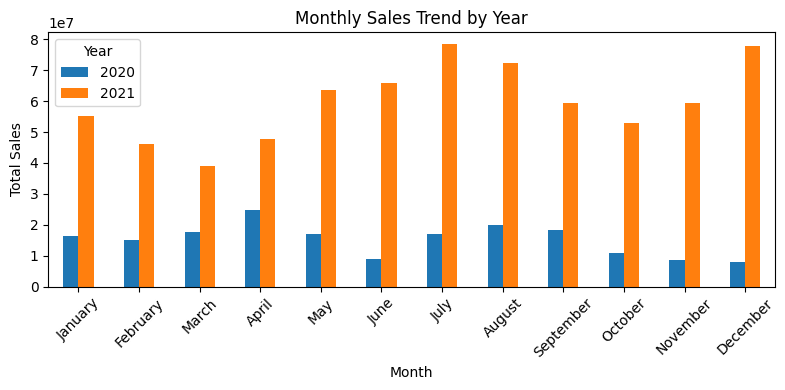

In [ ]:
# Monthly Sales per Year

monthly_pivot[[2020, 2021]].plot(kind='bar', figsize=(8,4))
plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [ ]:
# Average Sales per Month

avg_sales_month = df.groupby("Month_Name", observed=False).agg(
    Average_Sales=("Total Sales", "mean")
).reset_index()

avg_sales_month

,Month_Name,Average_Sales
0,January,83018.748
1,February,78737.311
2,March,70834.300
3,April,86016.611
4,May,98180.116
5,June,102534.118
6,July,123360.070
7,August,108049.474
8,September,94249.343
9,October,78514.783


In [ ]:
# Average Sales and Units per day of the week

avg_sales_day = df.groupby("Day_Name", observed=False).agg(
    Average_Sales=("Total Sales", "mean"),
    Average_Units=("Units Sold", "mean")
).reset_index()

avg_sales_day

,Day_Name,Average_Sales,Average_Units
0,Monday,90156.811,252.490
1,Tuesday,92038.985,251.881
2,Wednesday,89238.087,259.551
3,Thursday,108475.890,276.821
4,Friday,102863.323,267.447
5,Saturday,83816.616,242.779
6,Sunday,86343.876,248.101


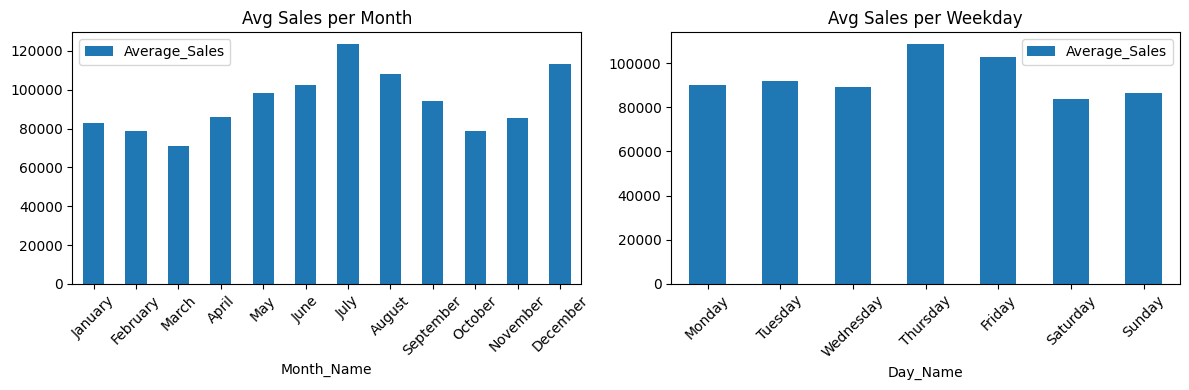

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Monthly
avg_sales_month.plot(kind="bar", x="Month_Name", y= "Average_Sales", ax=axes[0])
axes[0].set_title("Avg Sales per Month")
axes[0].tick_params(axis='x', rotation=45)

# Weekday
avg_sales_day.plot(kind="bar", x="Day_Name", y="Average_Sales", ax=axes[1])
axes[1].set_title("Avg Sales per Weekday")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The analysis of **average sales per month** highlights variations in transaction value throughout the year. The lowest average sales are observed in March, while the highest values occur in July and December. This pattern suggests that certain periods are associated with higher-value transactions, possibly due to bulk purchasing, seasonal demand, or a shift toward higher-priced products.

The distribution of **average sales by weekday** reveals that sales tend to peak toward the end of the workweek, particularly on Thursdays and Fridays, while lower values are observed on weekends, especially Saturdays.

In [ ]:
# Total Sales and Average Operating Margin by year

sales_margin_year = df.groupby("Year").agg(
    Total_Sales = ("Total Sales", "sum"),
    Average_Operating_Margin = ("Operating Margin", "mean")
).reset_index()
sales_margin_year

,Year,Total_Sales,Average_Operating_Margin
0,2020,182080675.000,0.404
1,2021,717821450.000,0.426


## Retailer Performance

In [ ]:
# Retailer Performance

retailer_stats = df.groupby('Retailer').agg(
    Total_Sales = ("Total Sales", "sum"),
    Average_Sales = ("Total Sales", 'mean'),
    Number_of_Transactions = ("Retailer", 'count'))
retailer_stats = retailer_stats.sort_values(by='Total_Sales').reset_index()
retailer_stats

,Retailer,Total_Sales,Average_Sales,Number_of_Transactions
0,Walmart,74558410.000,119102.891,626
1,Amazon,77698912.000,81874.512,949
2,Kohl's,102114753.000,99140.537,1030
3,Sports Direct,182470997.000,89798.719,2032
4,Foot Locker,220094720.000,83464.058,2637
5,West Gear,242964333.000,102343.864,2374


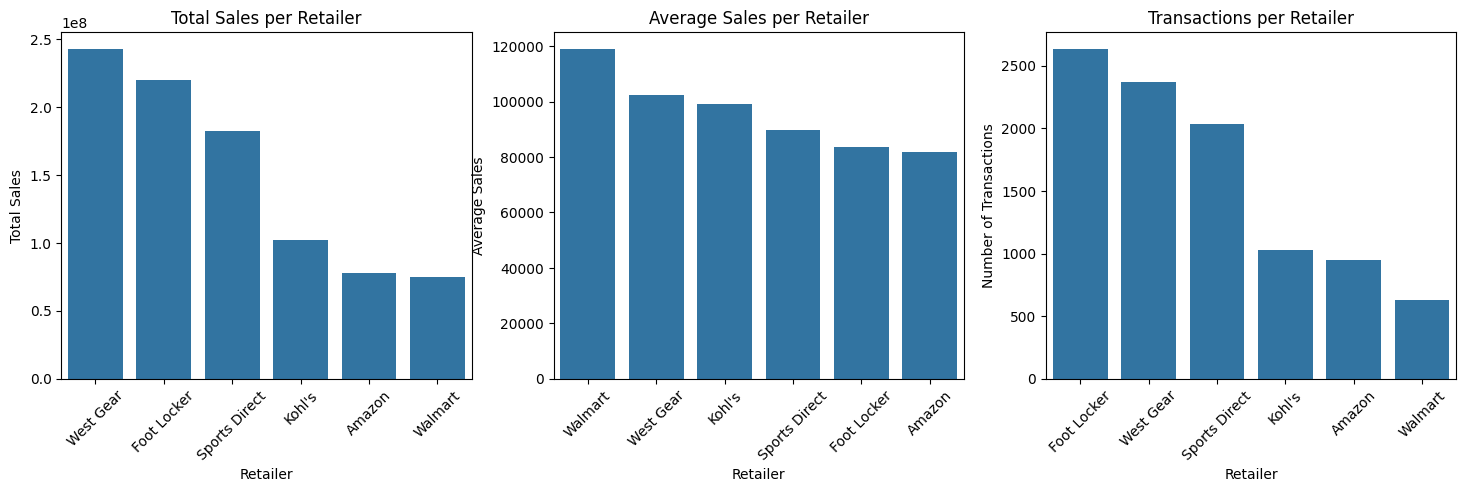

In [ ]:
# Graphs Total and Average Sales per Retailer

fig, axes = plt.subplots(1, 3, figsize=(18,4.5))

# Total Sales
sns.barplot(data=retailer_stats.sort_values(by='Total_Sales', ascending=False),
            x="Retailer", y="Total_Sales", ax=axes[0], errorbar=None)

axes[0].set_title("Total Sales per Retailer")
axes[0].set_xlabel("Retailer")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis='x', rotation=45)


# Average Sales
sns.barplot(data=retailer_stats.sort_values(by='Average_Sales', ascending=False),
            x="Retailer", y="Average_Sales", ax=axes[1], errorbar=None)

axes[1].set_title("Average Sales per Retailer")
axes[1].set_xlabel("Retailer")
axes[1].set_ylabel("Average Sales")
axes[1].tick_params(axis='x', rotation=45)


# Transactions
sns.barplot(data=retailer_stats.sort_values(by='Number_of_Transactions', ascending=False),
            x="Retailer", y="Number_of_Transactions", ax=axes[2], errorbar=None)

axes[2].set_title("Transactions per Retailer")
axes[2].set_xlabel("Retailer")
axes[2].set_ylabel("Number of Transactions")
axes[2].tick_params(axis='x', rotation=45)

The results highlight distinct retailer profiles: some retailers (e.g., Foot Locker, West Gear) drive volume and total revenue, while others (e.g., Walmart) contribute through higher-value transactions.

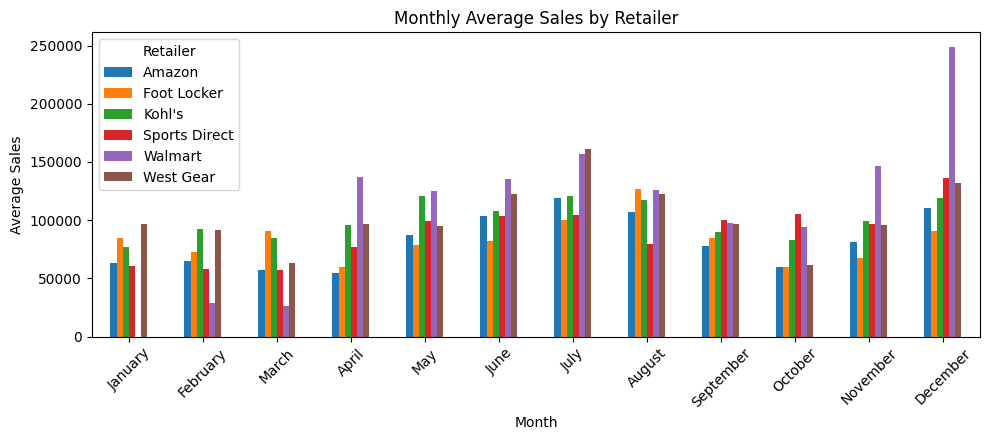

In [ ]:
# Average Sales per Month per Retailer

sales_month_retailer = df.groupby(["Month_Name","Retailer"], observed=False)["Total Sales"].mean().unstack()

sales_month_retailer.plot(kind='bar', figsize=(10,4.5))
plt.title("Monthly Average Sales by Retailer")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.legend(title='Retailer')
plt.tight_layout()
plt.show()

In [ ]:
# Best Period per Retailer in terms of sales

# Sales per retailer per month
retailer_month_sales = df.groupby(["Retailer", df["Invoice Date"].dt.to_period("M")]).agg(
    Total_Sales=("Total Sales", "sum")
).reset_index()

# Best month per retailer
best_month_per_retailer = retailer_month_sales.loc[
    retailer_month_sales.groupby("Retailer")["Total_Sales"].idxmax()
]

best_month_per_retailer

,Retailer,Invoice Date,Total_Sales
11,Amazon,2021-12,9715707.000
33,Foot Locker,2021-12,26135577.000
39,Kohl's,2021-05,17385959.000
60,Sports Direct,2021-09,28711985.000
64,Walmart,2020-04,8577117.000
92,West Gear,2021-01,23993565.000


## Sales Method Performance

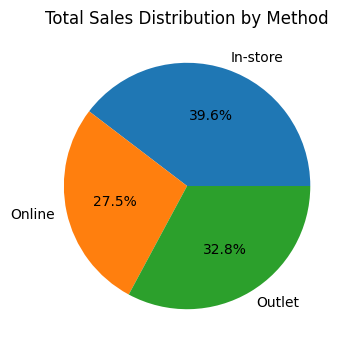

In [ ]:
# Sales Distribution per Method

df_salesmethod = df.groupby('Sales Method')['Total Sales'].sum().reset_index()

plt.figure(figsize=(8,4))
plt.pie(
    data = df_salesmethod,
    x = 'Total Sales',
    labels = 'Sales Method',
    autopct = '%1.1f%%',
)

plt.title('Total Sales Distribution by Method')
plt.show()

In [ ]:
# Average sales per day of the week per method

sales_day_method = df.groupby(["Day_Name","Sales Method"], observed=False)["Total Sales"].mean().unstack()
sales_day_method

# With unstack, we are able to turn the second level of the index (Sales Method) into columns

Sales Method,In-store,Online,Outlet
Day_Name,,,
Monday,188378.440,52291.123,98746.329
Tuesday,208766.981,44239.693,101545.114
Wednesday,191988.309,40091.963,96782.718
Thursday,261057.447,57320.217,107986.445
Friday,236925.000,63554.651,96310.395
Saturday,180980.392,42575.478,92319.523
Sunday,170766.064,53330.756,92134.592


## Product Category Performance

In [ ]:
# Analyze the sales growth for each product category from 2020 to 2021

df_product_year = df.groupby(['Product', 'Year']).agg(
    Total_Sales=('Total Sales', 'sum')
).reset_index()

pivot_sales = df_product_year.pivot(
    index="Product",
    columns="Year",
    values="Total_Sales"
)

pivot_sales["Growth_%"] = (
    (pivot_sales[2021] - pivot_sales[2020]) / pivot_sales[2020]) * 100

pivot_sales = pivot_sales.sort_values("Growth_%", ascending=False).round(2)

pivot_sales

Year,2020,2021,Growth_%
Product,,,
Men's Street Footwear,37823020.000,171003224.000,352.110
Women's Apparel,35190332.000,143848528.000,308.770
Men's Athletic Footwear,31794462.000,121879218.000,283.330
Men's Apparel,26216964.000,97511668.000,271.940
Women's Street Footwear,27426005.000,100576808.000,266.720
Women's Athletic Footwear,23629892.000,83002004.000,251.260


In [ ]:
# Most and Least Profitable Product Categories

product_profit = df.groupby("Product").agg(
    Total_Profit=("Operating Profit", "sum")
).reset_index()

product_profit = product_profit.sort_values("Total_Profit", ascending=False)

print("Most Profitable Product Category:")
display(product_profit.head(1))
print("")
print("\nLeast Profitable Product Category:")
display(product_profit.tail(1))

Most Profitable Product Category:


,Product,Total_Profit
2,Men's Street Footwear,82802260.620




Least Profitable Product Category:


,Product,Total_Profit
4,Women's Athletic Footwear,38975784.940


In [ ]:
# Demand Variability per Product Category

demand_variability = df.groupby("Product").agg(
    Average_Demand=("Units Sold", "mean"),
    Demand_STD=("Units Sold", "std"),
    Min_Demand=("Units Sold", "min"),
    Max_Demand=("Units Sold", "max")
).reset_index()

demand_variability["CV_Demand"] = (
    demand_variability["Demand_STD"] / demand_variability["Average_Demand"]
)

demand_variability = demand_variability.sort_values("CV_Demand", ascending=False)
demand_variability

,Product,Average_Demand,Demand_STD,Min_Demand,Max_Demand,CV_Demand
0,Men's Apparel,190.961,169.997,6,925,0.890
4,Women's Athletic Footwear,197.532,174.811,0,925,0.885
5,Women's Street Footwear,243.948,199.972,14,1100,0.820
1,Men's Athletic Footwear,270.513,216.709,23,1025,0.801
3,Women's Apparel,269.793,208.721,38,1100,0.774
2,Men's Street Footwear,368.522,254.278,84,1275,0.690


Men’s Street Footwear stands out as the highest-demand category, with an average of 368 units and the highest maximum demand observed, indicating strong and consistent market interest.

Men’s Apparel and Women’s Athletic Footwear show the highest variability (CV ≈ 0.89), indicating highly unpredictable demand patterns. On the other hand, Men’s Street Footwear has the lowest CV (0.69), suggesting relatively more stable and predictable demand.

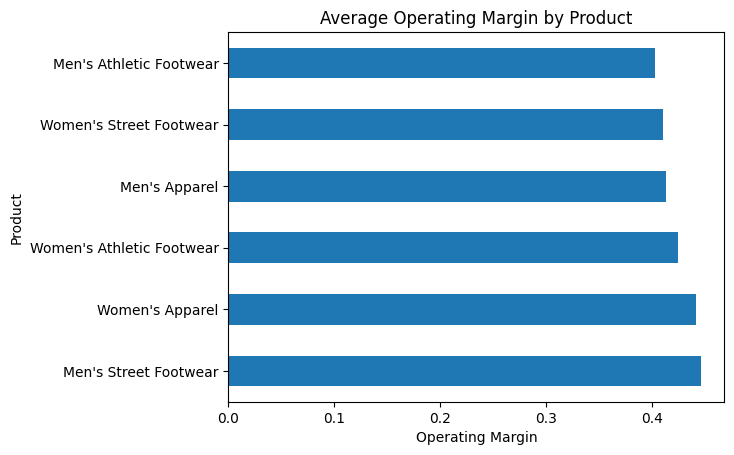

In [ ]:
# Operating Margin per Product

margin_product = df.groupby("Product")["Operating Margin"].mean().sort_values(ascending=False)

margin_product.plot(kind="barh")
plt.title("Average Operating Margin by Product")
plt.xlabel("Operating Margin")
plt.show()

## Regional Performance

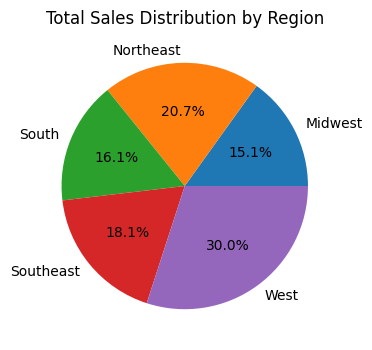

In [ ]:
# Sales per Region

region_sales = df.groupby("Region")["Total Sales"].sum().reset_index()

plt.figure(figsize=(8,4))
plt.pie(
    data = region_sales,
    x = 'Total Sales',
    labels = 'Region',
    autopct = '%1.1f%%',
)

plt.title('Total Sales Distribution by Region')
plt.show()

In [ ]:
# Cities with the most sales for each region

city_region_sales = df.groupby(["Region", "City"])["Total Sales"].sum().reset_index()
top_city_per_region = city_region_sales.loc[
    city_region_sales.groupby("Region")["Total Sales"].idxmax()
].sort_values(by="Total Sales", ascending=False)

top_city_per_region

,Region,City,Total Sales
20,Northeast,New York,39801235.000
52,West,San Francisco,34539220.000
38,Southeast,Miami,31600863.000
28,South,Houston,25456882.000
4,Midwest,Detroit,18625433.000


# **Demand Prediction with Random Forest**

In [ ]:
# Encoding Categorical Variables (Region, Retailer, Product)

df["Region"] = df["Region"].map({
"Northeast": 1,
"South": 2,
"West": 3,
"Midwest": 4,
"Southeast": 5,
 })

df["Retailer"] = df["Retailer"].map({
"Foot Locker": 1,
"Walmart": 2,
"Sports Direct": 3,
"West Gear": 4,
"Kohl's": 5,
"Amazon": 6,
 })

df["Product"] = df["Product"].map({
"Men's Street Footwear": 1,
"Men's Athletic Footwear": 2,
"Women's Street Footwear": 3,
"Women's Athletic Footwear": 4,
"Men's Apparel": 5,
"Women's Apparel": 6,
 })

display(df.head())

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,Year,Month,Day_of_week,Day_Name,Month_Name,YearMonth
0,1,1185732,2020-01-01,1,New York,New York,1,50.000,1200,600000.000,300000.000,0.500,In-store,2020,1,2,Wednesday,January,2020-01
1,1,1185732,2020-01-02,1,New York,New York,2,50.000,1000,500000.000,150000.000,0.300,In-store,2020,1,3,Thursday,January,2020-01
2,1,1185732,2020-01-03,1,New York,New York,3,40.000,1000,400000.000,140000.000,0.350,In-store,2020,1,4,Friday,January,2020-01
3,1,1185732,2020-01-04,1,New York,New York,4,45.000,850,382500.000,133875.000,0.350,In-store,2020,1,5,Saturday,January,2020-01
4,1,1185732,2020-01-05,1,New York,New York,5,60.000,900,540000.000,162000.000,0.300,In-store,2020,1,6,Sunday,January,2020-01


In [ ]:
# Define X and Y

X = df[["Price per Unit", "Month", "Region", "Retailer", "Product"]]
y = df["Units Sold"]
dates = df["YearMonth"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
display(X.head())
display(y.head())

Shape of X: (9648, 5)
Shape of y: (9648,)


,Price per Unit,Month,Region,Retailer,Product
0,50.000,1,1,1,1
1,50.000,1,1,1,2
2,40.000,1,1,1,3
3,45.000,1,1,1,4
4,60.000,1,1,1,5


,Units Sold
0,1200
1,1000
2,1000
3,850
4,900


In [ ]:
# Split the data into Test and Train Sets

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (7718, 5)
X_test shape : (1930, 5)
y_train shape: (7718,)
y_test shape : (1930,)


In [ ]:
# Build the Model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Make Predictions

y_pred = model.predict(X_test)

print("Predicted classes:")
print(y_pred[:10])

Predicted classes:
[642.565      257.92       185.95       498.445      175.95333333
  80.717      320.84       271.58333333 227.43666667 308.74      ]


In [ ]:
# Analyze Accuracy

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

summary_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Score": [mae, rmse, r2]
})

display(summary_df.style.format({"Score": "{:.3f}"}))

,Metric,Score
0,MAE,78.625
1,RMSE,124.017
2,R²,0.674


The Random Forest model shows strong predictive performance, with an R² of 0.674, indicating that approximately 67% of the variability in demand is explained by the selected features.

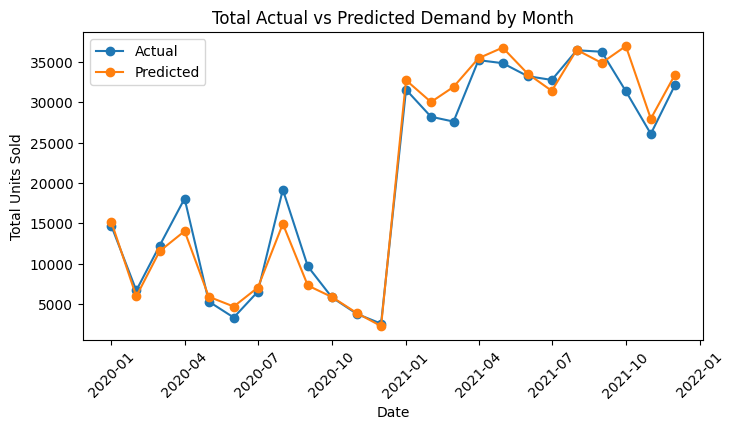

In [ ]:
# Real vs. Predicted Demand (Aggregated by Month)

results = pd.DataFrame({
    "Date": dates_test.astype(str),
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Date"] = pd.to_datetime(results["Date"])

monthly_results = results.groupby("Date").agg(
    Actual_Total=("Actual", "sum"),
    Predicted_Total=("Predicted", "sum")
).reset_index()

plt.figure(figsize=(8,4))
plt.plot(monthly_results["Date"], monthly_results["Actual_Total"], marker="o", label="Actual")
plt.plot(monthly_results["Date"], monthly_results["Predicted_Total"], marker="o", label="Predicted")

plt.title("Total Actual vs Predicted Demand by Month")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.show()

The model successfully captures the temporal dynamics of demand, closely following the observed trends over time. Predicted values align well with actual demand, particularly in high-volume periods, indicating that the model effectively learns seasonal and structural patterns. Minor deviations remain, especially in periods of demand volatility.

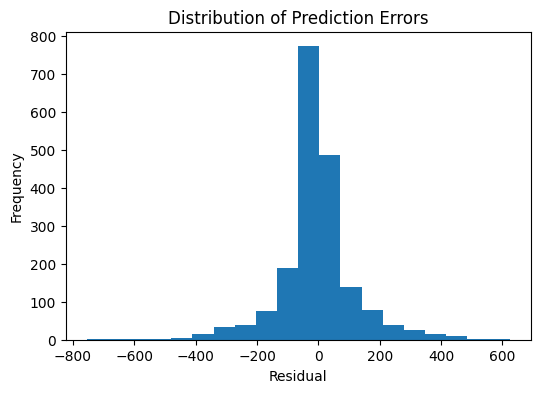

In [ ]:
# Error Histogram

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

The distribution of residuals is approximately centered around zero, indicating that the model does not exhibit systematic bias, that means it does not consistently overestimate or underestimate demand. However, the spread of errors suggests the presence of occasional large deviations, likely driven by demand spikes or unobserved factors.

In [ ]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
0,Price per Unit,0.459
1,Month,0.164
4,Product,0.148
3,Retailer,0.115
2,Region,0.113


Price per unit is the most influential variable, accounting for nearly 46% of the model’s predictive power. This highlights the strong relationship between pricing and demand. Temporal effects (month) also play a significant role, confirming the presence of seasonality. Additionally, product, retailer, and regional factors contribute meaningfully, reflecting heterogeneous demand patterns across different market segments.

# **Forecasting Methods**

## Prepare the time series

In [ ]:
# -----------------------------------------------
# DEMAND FORECASTING – Time Series
# -----------------------------------------------

# We build on df["Invoice Date"] and df["Total Sales"],
# which were already created in Cell 4 and Cell 13.

# Monthly aggregation: sum of sales per month
ts = df.groupby(df["Invoice Date"].dt.to_period("M"))["Units Sold"].sum()

# Convert Period index to real datetime (Prophet & statsmodels require this)
ts.index = ts.index.to_timestamp()

# Explicitly set monthly frequency (MS = Month Start)
ts = ts.asfreq("MS")

print("Time series created (Monthly Demand):")
ts.head()

Time series created (Monthly Demand):


,Units Sold
Invoice Date,
2020-01-01,48333
2020-02-01,37846
2020-03-01,46972
2020-04-01,54709
2020-05-01,35705


### Prophet Forecast

In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt


# Prophet expects exactly two columns: "ds" (date) and "y" (value)
df_prophet = ts.reset_index()
df_prophet.columns = ["ds", "y"]

print("Data for Prophet:")
print(df_prophet)

# Create and train the model
model = Prophet(
    yearly_seasonality=True,   # Detect seasonality across the year
    weekly_seasonality=False,  # Disable weekly (we have monthly data)
    daily_seasonality=False    # Disable daily (we have monthly data)
)
model.fit(df_prophet)

# Future: predict 6 months ahead
future = model.make_future_dataframe(periods=6, freq="MS")
forecast = model.predict(future)

# Display results (relevant columns only)
print("\nForecast:")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(9))




Data for Prophet:
           ds       y
0  2020-01-01   48333
1  2020-02-01   37846
2  2020-03-01   46972
3  2020-04-01   54709
4  2020-05-01   35705
5  2020-06-01   16269
6  2020-07-01   38219
7  2020-08-01   62307
8  2020-09-01   46125
9  2020-10-01   30167
10 2020-11-01   25152
11 2020-12-01   20545
12 2021-01-01  179299
13 2021-02-01  156113
14 2021-03-01  143988
15 2021-04-01  161717
16 2021-05-01  178900
17 2021-06-01  164745
18 2021-07-01  180481
19 2021-08-01  195414
20 2021-09-01  182425
21 2021-10-01  152834
22 2021-11-01  149350
23 2021-12-01  171246


INFO:prophet:n_changepoints greater than number of observations. Using 18.



Forecast:
           ds       yhat  yhat_lower  yhat_upper
21 2021-10-01 150725.953  146345.169  155491.405
22 2021-11-01 149941.582  145194.857  154270.550
23 2021-12-01 174757.560  170048.458  179276.336
24 2022-01-01 311649.691  306934.329  316247.297
25 2022-02-01 292544.087  287515.265  297209.493
26 2022-03-01 263844.893  259105.888  268268.294
27 2022-04-01 284271.212  279919.247  288992.034
28 2022-05-01 328680.657  324147.602  333234.162
29 2022-06-01 310249.648  305892.469  314705.245


### Visualization

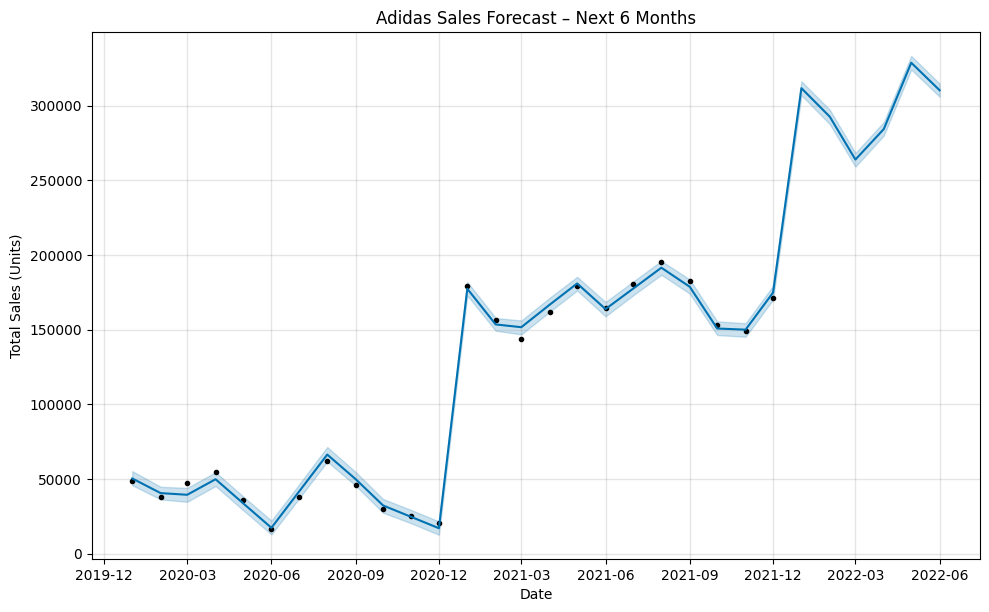

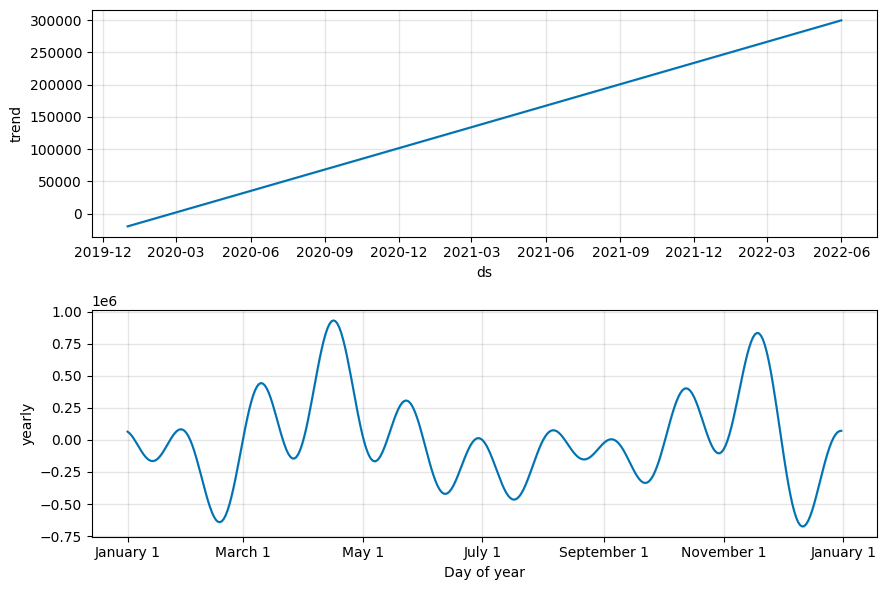

In [ ]:
# Visualize the forecast
model.plot(forecast)
plt.title("Adidas Sales Forecast – Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Total Sales (Units)")
plt.show()

# Show trend and seasonality separately
model.plot_components(forecast)
plt.show()

The forecast shows a strong upward trend in sales, indicating sustained growth over time.
A structural increase is observed around 2021, suggesting a shift in demand levels.


In addition to the trend, clear seasonal fluctuations are present, with recurring peaks and drops throughout the year.


The forecast projects that sales will continue to grow but not in a linear way, as they are influenced by these seasonal patterns.
This suggests that demand is both increasing and cyclical, requiring planning that accounts for both growth and variability.

## Model Comparision (MAE & RMSE)

In [ ]:
# -----------------------------------------------
# METHODOLOGY COMPARISON – Prophet vs Moving Average vs SARIMA
# -----------------------------------------------

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import numpy as np
import pandas as pd

# Train/Test Split: last 3 months = test
train = ts[:-3]
test = ts[-3:]

# --- Model 1: Moving Average ---
# Calculate moving average of the last 3 points in the training set
ma_pred = train.rolling(window=3).mean().iloc[-1]

# Extend this single moving average value to forecast the 3 test points
pred_ma = [ma_pred] * len(test)

# --- Model 2: SARIMA ---
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,12))
sarima_result = sarima_model.fit(disp=False)
pred_sarima = sarima_result.forecast(steps=len(test))

# --- Model 3: Prophet ---
# Prophet must be trained only on the training set for a fair comparison
df_prophet_train = train.reset_index()
df_prophet_train.columns = ["ds", "y"]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(df_prophet_train)

# Forecast the same number of periods as the test set
future_prophet = prophet_model.make_future_dataframe(periods=len(test), freq="MS")
forecast_prophet = prophet_model.predict(future_prophet)

# Keep only the forecasted values that correspond to the test period
pred_prophet = forecast_prophet["yhat"].tail(len(test)).values

# --- Performance Metrics ---
results = {
    "Moving Average": {
        "MAE": mean_absolute_error(test.values, pred_ma),
        "RMSE": np.sqrt(mean_squared_error(test.values, pred_ma))
    },
    "SARIMA": {
        "MAE": mean_absolute_error(test.values, pred_sarima),
        "RMSE": np.sqrt(mean_squared_error(test.values, pred_sarima))
    },
    "Prophet": {
        "MAE": mean_absolute_error(test.values, pred_prophet),
        "RMSE": np.sqrt(mean_squared_error(test.values, pred_prophet))
    }
}

print("=== Model Comparison ===\n")
print(f"{'Model':<20} {'MAE':>15} {'RMSE':>15}")
print("-" * 52)

for model_name, metrics in results.items():
    print(f"{model_name:<20} ${metrics['MAE']:>13,.0f} ${metrics['RMSE']:>13,.0f}")

print("\n→ Lower MAE and RMSE = better model")



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
INFO:prophet:n_changepoints greater than number of observations. Using 15.


=== Model Comparison ===

Model                            MAE            RMSE
----------------------------------------------------
Moving Average       $       28,297 $       29,883
SARIMA               $       17,475 $       20,496
Prophet              $       83,388 $      104,182

→ Lower MAE and RMSE = better model


The comparison shows that SARIMA outperforms the other models, as it has the lowest MAE and RMSE values.
This indicates that SARIMA captures the underlying sales patterns more accurately.


Moving Average performs moderately but fails to capture complex trends.
Prophet shows the highest error, likely due to the limited amount of data available.


Therefore, **SARIMA is the most reliable model** for forecasting in this case.

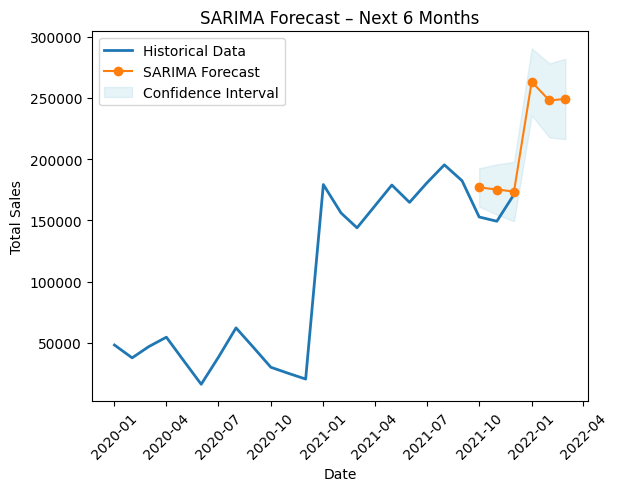

In [ ]:
# Forecast SARIMA next 6 months
sarima_forecast = sarima_result.get_forecast(steps=6)

# Predictions
sarima_pred = sarima_forecast.predicted_mean

# Confidence Intervals
sarima_ci = sarima_forecast.conf_int()

plt.figure()

# Data
plt.plot(ts.index, ts, label="Historical Data", linewidth=2)

# Forecast
plt.plot(sarima_pred.index, sarima_pred, label="SARIMA Forecast", marker="o")

# Plot the graph
plt.fill_between(
    sarima_ci.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    color="lightblue",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast – Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)

plt.show()

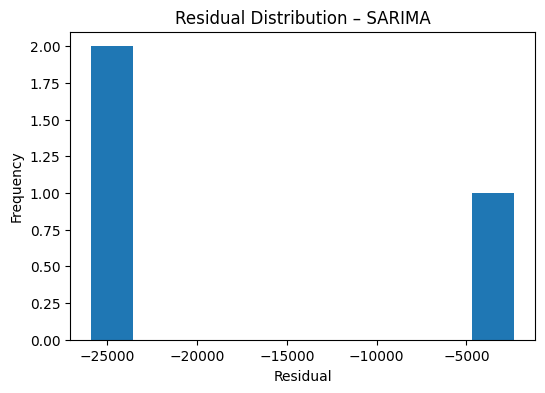

In [ ]:
import matplotlib.pyplot as plt

# Residuals for SARIMA
residuals_sarima = test.values - pred_sarima

plt.figure(figsize=(6,4))
plt.hist(residuals_sarima, bins=10)
plt.title("Residual Distribution – SARIMA")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


The residual distribution is based on a very small test set, which limits the analysis.

Although the residuals appear negative, indicating slight underestimation, the sample size is too small to draw strong conclusions about the model's error distribution. However, this still provides a basic indication of the model's prediction performance.

-----------------------------------------------
FINAL INSIGHT – FORECASTING
-----------------------------------------------

Conclusion:
The forecasting analysis shows that sales follow both a growth trend and recurring seasonal patterns. This indicates that demand is not constant and requires dynamic planning.

Understanding these patterns can support better inventory management and help anticipate periods of higher and lower demand.